# Import Libraries

In [1]:
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.optimizers import Adam



# Set the random seed

In [2]:
tf.random.set_seed(42)
AUTOTUNE = tf.data.experimental.AUTOTUNE

# Create Predetermined Function

## Loss Function

In [3]:
# Make SSIM loss function that supports different image dimensions
class SSIM_loss() :
    def __init__(self, img_dims) :
        self.img_dims = img_dims

    def __call__(self, y_true, y_pred) :
        return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))

    def get_config(self) :
        return {'img_dims': self.img_dims}

    @classmethod
    def from_config(cls, config) :
        return cls(**config)

# Load Data

In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

## Filter to only include the label we need (0, 1)

In [5]:
# Filter labels to only include T shirts (0) and Trousers (1)
train_images = train_images[(train_labels == 0) | (train_labels == 1)]
train_labels = train_labels[(train_labels == 0) | (train_labels == 1)]

test_images = test_images[(test_labels == 0) | (test_labels == 1)]
test_labels = test_labels[(test_labels == 0) | (test_labels == 1)]

train_images = train_images / 255.0
test_images = test_images / 255.0

## Combine the train and test data

In [6]:
# Combine the train and test images to create a single dataset
combined_images, combined_labels = tf.concat([train_images, test_images], axis=0), tf.concat([train_labels, test_labels], axis=0)

# EDA

## Visualize the data

In [7]:
class_names = ['T-shirt/top', 'Trouser']

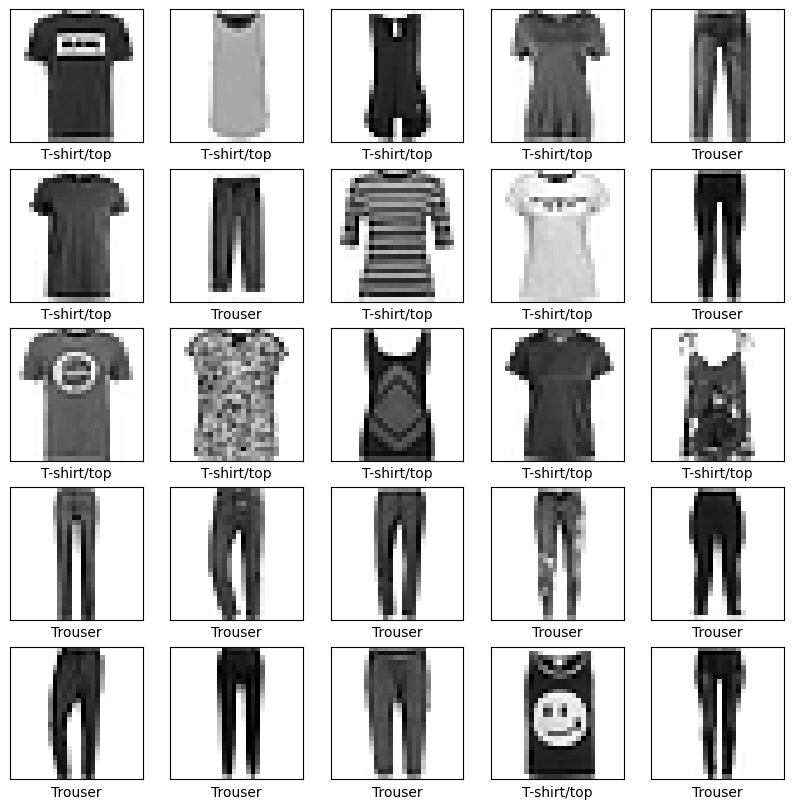

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(combined_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[combined_labels[i]])
plt.show()

# Preprocess Data

## Reshape the data

In [9]:
combined_images = tf.reshape(combined_images, (combined_images.shape[0], 28, 28, 1))

## Split the data into train, validation, and test sets

In [10]:
# Split the dataset into training and validation sets

train_size = int(0.8 * combined_images.shape[0])
train_images, val_images = combined_images[:train_size], combined_images[train_size:]
train_labels, val_labels = combined_labels[:train_size], combined_labels[train_size:]

# Split validation set into validation and test sets
val_size = int(0.5 * val_images.shape[0])
val_images, test_images = val_images[:val_size], val_images[val_size:]
val_labels, test_labels = val_labels[:val_size], val_labels[val_size:]

# Base Autoencoder Model

In [13]:
class Autoencoder(Model) :
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            Conv2D(32, (3, 3), activation='relu'),
            MaxPooling2D((14, 14)),
            Flatten(),
            Dense(128, activation='relu')
        ], name='encoder')
        self.decoder = tf.keras.Sequential([
            Dense(6272, activation='relu', input_shape=(128,)),
            Reshape((14, 14, 32)),
            UpSampling2D((2, 2)),
            Conv2D(32, (1, 1), activation='relu'),
            Conv2D(1, (1, 1), activation='sigmoid')
        ], name='decoder')
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

## Compliling Model

In [14]:
base_autoencoder = Autoencoder()
ssimLoss = SSIM_loss(train_images.shape[1:])
# Autoencoder model summary
base_autoencoder.compile(optimizer='adam', loss=ssimLoss, metrics=['accuracy'])
base_autoencoder.build(train_images.shape)

## Model Summary

In [15]:
base_autoencoder.get_layer('encoder').summary()

Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (11200, 26, 26, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (11200, 1, 1, 32)        0         
 )                                                               
                                                                 
 flatten (Flatten)           (11200, 32)               0         
                                                                 
 dense (Dense)               (11200, 128)              4224      
                                                                 
Total params: 4,544
Trainable params: 4,544
Non-trainable params: 0
_________________________________________________________________


In [16]:
base_autoencoder.get_layer('decoder').summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 6272)              809088    
                                                                 
 reshape (Reshape)           (None, 14, 14, 32)        0         
                                                                 
 up_sampling2d (UpSampling2D  (None, 28, 28, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        1056      
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 1)         33        
                                                                 
Total params: 810,177
Trainable params: 810,177
Non-trainable params: 0
_____________________________________________________

## Model Training

In [17]:
callabacks = [
    EarlyStopping(monitor='val_loss', patience=3),
]

base_his = base_autoencoder.fit(train_images, train_images, epochs=100, batch_size=128, validation_data=(val_images, val_images), callbacks=callabacks)

Epoch 1/100
88/88 [==============================] - 7s 32ms/step - loss: 0.7200 - accuracy: 0.4756 - val_loss: 0.5961 - val_accuracy: 0.5168
Epoch 2/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5697 - accuracy: 0.5174 - val_loss: 0.5527 - val_accuracy: 0.5185
Epoch 3/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5491 - accuracy: 0.5178 - val_loss: 0.5413 - val_accuracy: 0.5191
Epoch 4/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5395 - accuracy: 0.5179 - val_loss: 0.5333 - val_accuracy: 0.5197
Epoch 5/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5310 - accuracy: 0.5190 - val_loss: 0.5239 - val_accuracy: 0.5191
Epoch 6/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5224 - accuracy: 0.5196 - val_loss: 0.5167 - val_accuracy: 0.5205
Epoch 7/100
88/88 [==============================] - 2s 25ms/step - loss: 0.5149 - accuracy: 0.5207 - val_loss: 0.5088 - val_accuracy: 0.5223
Epoch 

## Model Evaluation

### Training Loss VS Validation Loss Plot

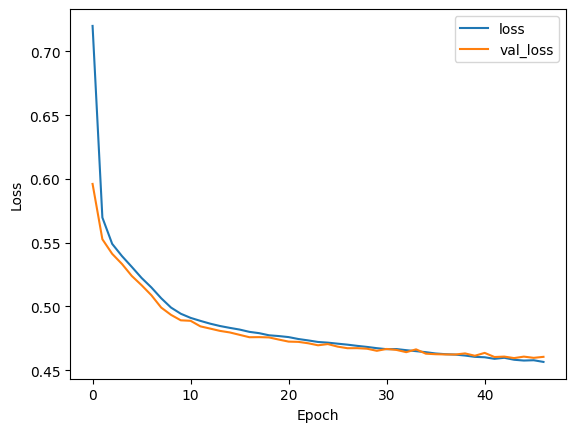

In [18]:
plt.plot(base_his.history['loss'], label='loss')
plt.plot(base_his.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Inference

In [19]:
predictions = base_autoencoder.predict(test_images)

44/44 [==============================] - 0s 4ms/step


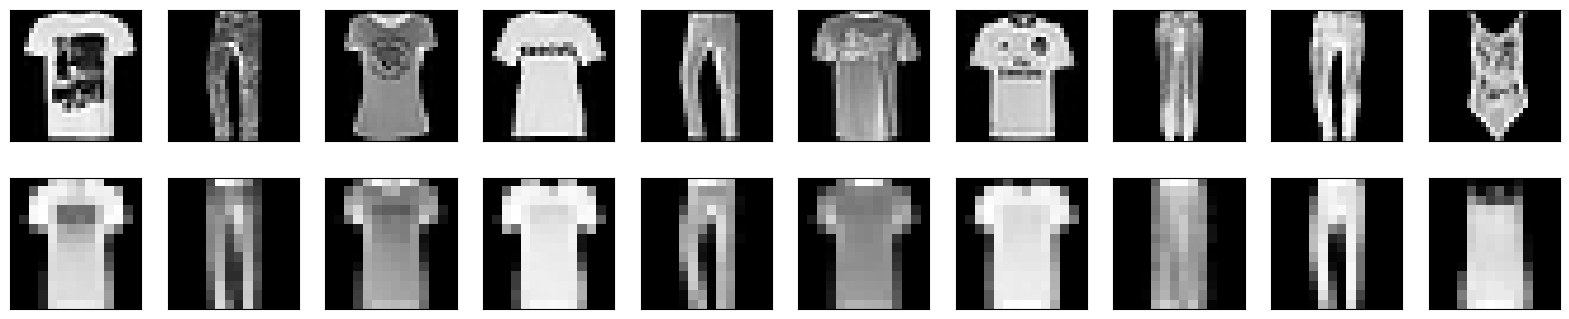

In [20]:
# Show predicted vs original images
plt.figure(figsize=(20, 4))
for i in range(10):
    # Display original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(test_images[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(predictions[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

## Save Model

In [21]:
base_autoencoder.save_weights('base_autoencoder.h5')

# Tuned Autoencoder Model

- Use learning rate scheduler
- Decrease the learning rate
- Decrease the batch size

## Learning Rate Scheduler

In [22]:
class lr_polynomial_decay:
	def __init__(self, epochs=100, initial_learning_rate=0.01, power=1.0):
		# store the maximum number of epochs, base learning rate,
		# and power of the polynomial
		self.epochs = epochs
		self.initial_learning_rate = initial_learning_rate
		self.power = power

	def __call__(self, epoch):
		# compute the new learning rate based on polynomial decay
		decay = (1 - (epoch / float(self.epochs))) ** self.power
		updated_eta = self.initial_learning_rate * decay
		# return the new learning rate
		return float(updated_eta)

In [23]:
initial_learning_rate = 0.005
cuScheduler = lr_polynomial_decay(epochs=100, initial_learning_rate=initial_learning_rate, power=1.0)

## Compliling Model

In [25]:
mod_autoencoder = Autoencoder()
ssimLoss = SSIM_loss(train_images.shape[1:])

# initialize the model with the base autoencoder weights

mod_autoencoder.compile(optimizer=Adam(learning_rate=initial_learning_rate), loss=ssimLoss, metrics=['accuracy'])
mod_autoencoder.build(train_images.shape)
mod_autoencoder.load_weights('base_autoencoder.h5')

## Model Summary

In [26]:
mod_autoencoder.get_layer('encoder').summary()

Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (11200, 26, 26, 32)       320       
                                                                 
 max_pooling2d_2 (MaxPooling  (11200, 1, 1, 32)        0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (11200, 32)               0         
                                                                 
 dense_4 (Dense)             (11200, 128)              4224      
                                                                 
Total params: 4,544
Trainable params: 4,544
Non-trainable params: 0
_________________________________________________________________


In [27]:
mod_autoencoder.get_layer('decoder').summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 6272)              809088    
                                                                 
 reshape_2 (Reshape)         (None, 14, 14, 32)        0         
                                                                 
 up_sampling2d_2 (UpSampling  (None, 28, 28, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 28, 28, 32)        1056      
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 1)         33        
                                                                 
Total params: 810,177
Trainable params: 810,177
Non-trainable params: 0
_____________________________________________________

## Training Model

In [28]:
callabacks = [
    EarlyStopping(monitor='val_loss', patience=3, verbose=1),
    LearningRateScheduler(cuScheduler, verbose=1),
]

mod_his = mod_autoencoder.fit(train_images, train_images, epochs=100, batch_size=32, validation_data=(val_images, val_images), callbacks=callabacks)


Epoch 1: LearningRateScheduler setting learning rate to 0.005.
Epoch 1/100
350/350 [==============================] - 5s 11ms/step - loss: 0.4789 - accuracy: 0.5219 - val_loss: 0.4747 - val_accuracy: 0.5237 - lr: 0.0050

Epoch 2: LearningRateScheduler setting learning rate to 0.00495.
Epoch 2/100
350/350 [==============================] - 3s 9ms/step - loss: 0.4729 - accuracy: 0.5221 - val_loss: 0.4673 - val_accuracy: 0.5250 - lr: 0.0049

Epoch 3: LearningRateScheduler setting learning rate to 0.0049.
Epoch 3/100
350/350 [==============================] - 3s 9ms/step - loss: 0.4682 - accuracy: 0.5223 - val_loss: 0.4633 - val_accuracy: 0.5239 - lr: 0.0049

Epoch 4: LearningRateScheduler setting learning rate to 0.00485.
Epoch 4/100
350/350 [==============================] - 3s 9ms/step - loss: 0.4655 - accuracy: 0.5224 - val_loss: 0.4656 - val_accuracy: 0.5259 - lr: 0.0049

Epoch 5: LearningRateScheduler setting learning rate to 0.0048.
Epoch 5/100
350/350 [============================

## Model Evaluation

### Training Loss VS Validation Loss Plot

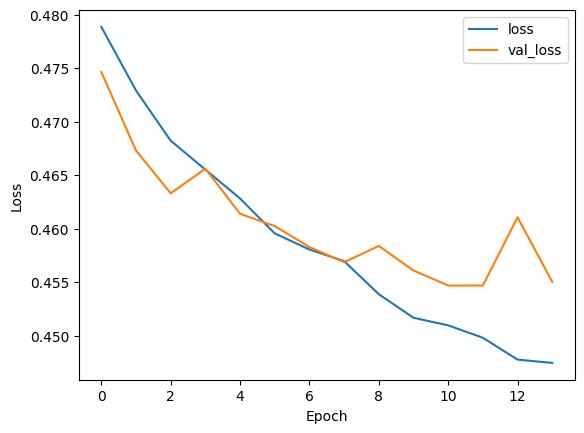

In [29]:
plt.plot(mod_his.history['loss'], label='loss')
plt.plot(mod_his.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Inference

In [30]:
predictions = mod_autoencoder.predict(test_images)

44/44 [==============================] - 0s 2ms/step


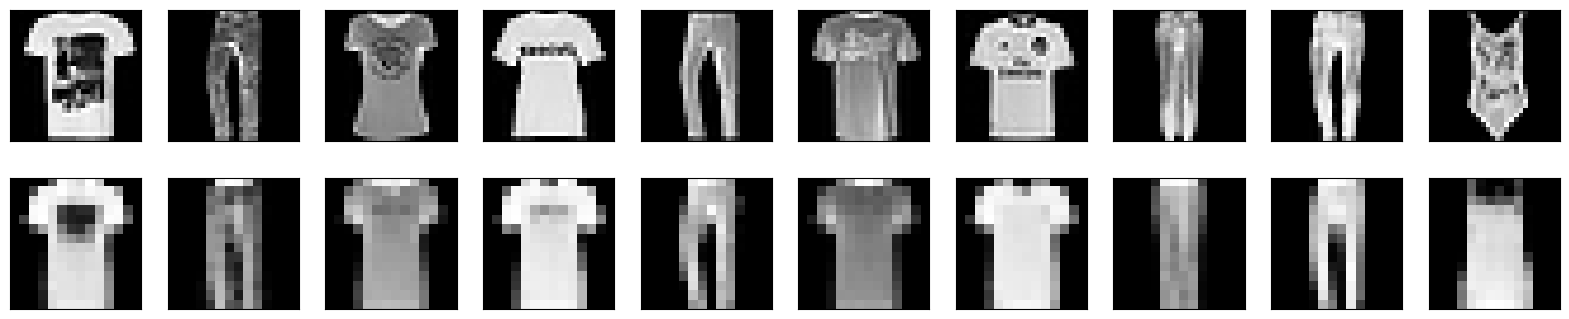

In [31]:
# Show predicted vs original images
plt.figure(figsize=(20, 4))
for i in range(10):
    # Display original
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(test_images[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(predictions[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)